In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dateutil.relativedelta import relativedelta
import statsmodels.api as sm

# ------------------------------
# SETTINGS (edit these as needed)
# ------------------------------
CSV_PATH     = "SPY.csv"
TICKER       = "SPY"
RV_COL       = "RV_daily"         # after your renaming
HAR_WINDOWS = [1, 2, 3, 4, 5, 10, 16, 22, 32, 44, 66, 88]        # classic HAR; change to your candidate set if desired
BASE_LAG = 1                      # the HAR "daily" block is fixed at 1
RATIO_MONTH_PER_WEEK = 22 / 5
TRAIN_YEARS  = 4                  # initial training length
EPS_POSITIVE = 1e-12              # for log safety / positivity
SAVE_SPLIT_METRICS = True         # also write per-month metrics to CSV

In [12]:
# ------------------------------
# DATA LOADING
# ------------------------------
def load_rv_dataframe(csv_path: str, rv_col: str = "RV_daily") -> pd.DataFrame:
    rv = pd.read_csv(csv_path)
    rv = rv[["Date", "Volatility", "Type"]].copy()
    rv.rename(columns={"Volatility": rv_col}, inplace=True)
    rv = rv[rv["Type"] == "QMLE-Trade"].copy()
    rv.drop(columns=["Type"], inplace=True)
    rv = rv.set_index("Date")
    rv.index = pd.to_datetime(rv.index)
    rv.index.name = "date"
    rv.sort_index(inplace=True)
    rv = rv[pd.to_numeric(rv[rv_col], errors="coerce") > 0].copy()
    rv[rv_col] = rv[rv_col].astype(float)
    return rv

In [13]:
# ------------------------------
# FEATURE CONSTRUCTION (build once for ALL candidate windows)
# ------------------------------
def make_candidate_features(df: pd.DataFrame,
                            rv_col: str,
                            candidates: list[int]) -> tuple[pd.DataFrame, list[str]]:
    out = df.copy()
    y = out[rv_col]

    # rolling means up to t-1 for all candidates
    for k in sorted(set(candidates)):
        out[f"har_{k}"] = y.shift(1).rolling(k, min_periods=k).mean()

    # drop rows where any candidate feature is missing
    feat_mean_cols = [f"har_{k}" for k in sorted(set(candidates))]
    out = out.dropna(subset=feat_mean_cols).copy()

    # log target and log features
    out["y_log"] = np.log(out[rv_col].clip(lower=EPS_POSITIVE))
    for k in sorted(set(candidates)):
        out[f"xlog_{k}"] = np.log(out[f"har_{k}"].clip(lower=EPS_POSITIVE))

    xlog_cols = [f"xlog_{k}" for k in sorted(set(candidates))]
    return out, xlog_cols

In [14]:
# ------------------------------
# METRICS
# ------------------------------
def mse(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean((y_true - y_pred)**2))

def qlike(y_true, y_pred) -> float:
    y = np.clip(np.asarray(y_true, dtype=float), EPS_POSITIVE, None)
    f = np.clip(np.asarray(y_pred, dtype=float), EPS_POSITIVE, None)
    return float(np.mean(y / f - np.log(y / f) - 1.0))

In [15]:
# ------------------------------
# SPLITTING
# ------------------------------
def month_periods_present(idx: pd.DatetimeIndex) -> pd.PeriodIndex:
    return idx.to_period("M").unique().sort_values()

def initial_test_month(first_date: pd.Timestamp, train_years: int) -> pd.Period:
    start = first_date + relativedelta(years=train_years)
    return start.to_period("M")

In [16]:
# ------------------------------
# UTILS
# ------------------------------
def nearest_candidate(target: int, candidates: list[int], min_val: int | None = None) -> int:
    cands = [c for c in candidates if (min_val is None or c >= min_val)]
    if not cands:
        # fallback to closest overall if constraint empties the set
        cands = candidates[:]
    return min(cands, key=lambda c: abs(c - target))


In [17]:
# ------------------------------
# BIC-BASED LAG SELECTION
# ------------------------------
def def_calculate_BIC(train_df: pd.DataFrame,
                      candidates: list[int],
                      base_lag: int = BASE_LAG,
                      ratio_month_per_week: float = RATIO_MONTH_PER_WEEK) -> dict:
    """
    Choose k2 from candidates (excluding base_lag) by minimizing BIC in OLS on log(RV),
    using regressors: const + xlog_base + xlog_k2 + xlog_k3,
    where k3 is the nearest candidate to k2 * (22/5) and k3 >= k2.

    Returns dict with keys: 'best_windows' (list[int]), 'bic', 'k2', 'k3'
    """
    assert base_lag in candidates, "BASE_LAG must be in candidate set."

    best = {"bic": np.inf, "k2": None, "k3": None}
    for k2 in candidates:
        if k2 == base_lag:
            continue

        # ---- If you actually intended to use the BIC *value* to compute the third lag,
        # swap the next two lines after you know BIC. (Not recommended.)
        k3_target = int(round(k2 * ratio_month_per_week))
        k3 = nearest_candidate(k3_target, candidates, min_val=max(k2, base_lag))

        # ensure we have distinct, valid columns
        cols = [f"xlog_{base_lag}", f"xlog_{k2}", f"xlog_{k3}"]
        if len(set(cols)) < 3:
            continue  # skip degenerate combos

        sub = train_df.dropna(subset=["y_log"] + cols)
        if sub.empty:
            continue

        X = sm.add_constant(sub[cols], has_constant="add")
        y = sub["y_log"].values
        res = sm.OLS(y, X.values, missing="drop").fit()
        bic_val = float(res.bic)

        if bic_val < best["bic"]:
            best = {"bic": bic_val, "k2": k2, "k3": k3}

    if best["k2"] is None:
        # fallback: classic HAR(1,5,22)
        best = {"bic": np.nan, "k2": 5 if 5 in candidates else sorted(candidates)[1],
                "k3": 22 if 22 in candidates else nearest_candidate(22, candidates, min_val=5)}

    return {
        "best_windows": [base_lag, best["k2"], best["k3"]],
        "bic": best["bic"],
        "k2": best["k2"],
        "k3": best["k3"],
    }

In [18]:
# ------------------------------
# FIT & PREDICT
# ------------------------------
def fit_ols_and_predict(X_train: pd.DataFrame, ylog_train: pd.Series,
                        X_test: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    Xtr = sm.add_constant(X_train, has_constant="add")
    Xte = sm.add_constant(X_test,  has_constant="add")
    model = sm.OLS(ylog_train.values, Xtr.values, missing="drop")
    res = model.fit()
    yhat_log_tr = res.predict(Xtr.values)
    yhat_log_te = res.predict(Xte.values)
    return np.exp(yhat_log_tr), np.exp(yhat_log_te)

In [19]:
# ------------------------------
# MAIN WALK-FORWARD (with BIC lag selection each month)
# ------------------------------
def expanding_har_forecast_bic(df_features: pd.DataFrame,
                               candidates: list[int],
                               rv_col: str,
                               train_years: int = 4,
                               ticker: str = "SPY") -> tuple[pd.DataFrame, pd.DataFrame]:
    periods = month_periods_present(df_features.index)
    first = df_features.index.min()
    start_test_per = initial_test_month(first, train_years)
    test_months = [p for p in periods if p >= start_test_per]

    oos_rows, split_rows = [], []
    for p in test_months:
        test_mask = (df_features.index.to_period("M") == p)
        if not test_mask.any():
            continue

        test_dates = df_features.index[test_mask]
        test_start = test_dates.min()
        train_mask = (df_features.index < test_start)

        train_df = df_features.loc[train_mask]
        test_df  = df_features.loc[test_mask]

        # calendar sufficiency check
        min_train_end = test_start - relativedelta(years=train_years)
        if train_df.index.min() is None or train_df.index.min() > min_train_end or len(train_df) < 30:
            continue

        # ---- BIC-based lag selection on TRAIN ONLY
        choice = def_calculate_BIC(train_df, candidates=candidates, base_lag=BASE_LAG)
        k1, k2, k3 = choice["best_windows"]

        X_cols = [f"xlog_{k1}", f"xlog_{k2}", f"xlog_{k3}"]

        # ensure columns exist and have data
        train_sub = train_df.dropna(subset=["y_log"] + X_cols)
        test_sub  = test_df.dropna(subset=["y_log"] + X_cols)

        if train_sub.empty or test_sub.empty:
            continue

        # fit & predict
        yhat_tr, yhat_te = fit_ols_and_predict(train_sub[X_cols], train_sub["y_log"], test_sub[X_cols])

        # metrics
        y_tr = train_sub[rv_col].values
        y_te = test_sub[rv_col].values
        ins_mse = mse(y_tr, yhat_tr)
        ins_qlk = qlike(y_tr, yhat_tr)
        oos_mse = mse(y_te, yhat_te)
        oos_qlk = qlike(y_te, yhat_te)

        split_rows.append({
            "test_month": str(p),
            "n_train": int(len(train_sub)),
            "n_test": int(len(test_sub)),
            "lag_1": int(k1),
            "lag_2": int(k2),
            "lag_3": int(k3),
            "BIC_selected": float(choice["bic"]) if np.isfinite(choice["bic"]) else np.nan,
            "MSE_in": ins_mse,
            "QLIKE_in": ins_qlk,
            "MSE_oos": oos_mse,
            "QLIKE_oos": oos_qlk
        })

        # stash OOS rows
        tmp = pd.DataFrame({
            "ticker": ticker,
            "date": test_sub.index,
            "real_RV": y_te,
            "pred_RV": yhat_te
        })
        oos_rows.append(tmp)

    oos_forecasts = pd.concat(oos_rows, axis=0).sort_values("date").reset_index(drop=True) if oos_rows else pd.DataFrame(columns=["ticker","date","real_RV","pred_RV"])
    split_metrics = pd.DataFrame(split_rows)
    return oos_forecasts, split_metrics


[Saved] SPY_HAR_forecast.csv with 6187 OOS rows

=== Overall OOS metrics ===
OOS MSE   : 0.001516
OOS QLIKE : 0.028963
[Saved] SPY_HAR_split_metrics.csv


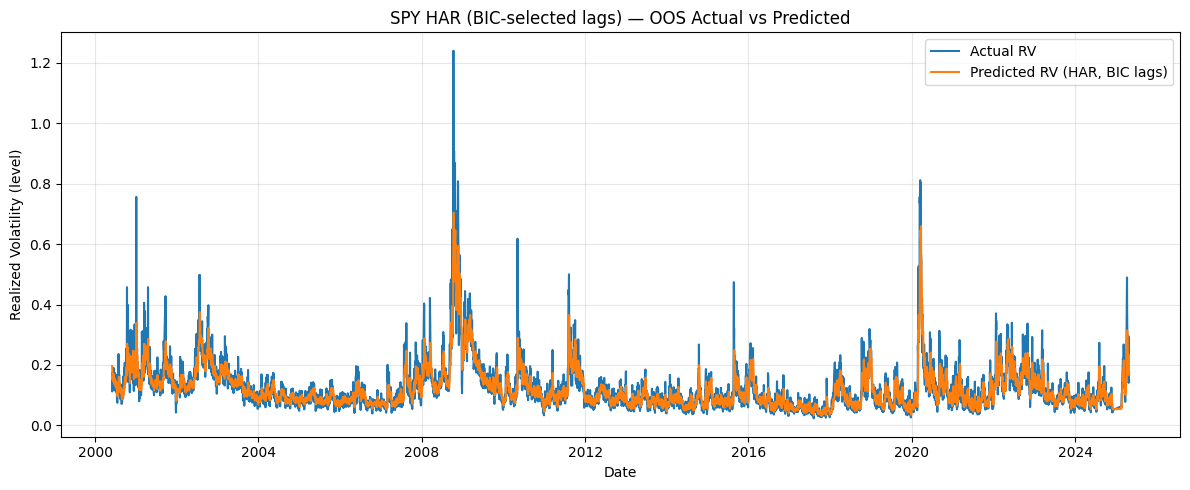

In [20]:
# ------------------------------
# DRIVER
# ------------------------------
def main():
    rv = load_rv_dataframe(CSV_PATH, RV_COL)

    # Build features for ALL candidate windows (once)
    feats, _ = make_candidate_features(rv, RV_COL, HAR_WINDOWS)

    # Run expanding-window with BIC-based lag selection
    oos_fcst, split_metrics = expanding_har_forecast_bic(
        df_features=feats,
        candidates=HAR_WINDOWS,
        rv_col=RV_COL,
        train_years=TRAIN_YEARS,
        ticker=TICKER
    )

    # Save forecasts
    out_name = f"{TICKER}_HAR_forecast.csv"
    oos_fcst.to_csv(out_name, index=False)
    print(f"[Saved] {out_name} with {len(oos_fcst)} OOS rows")

    if not split_metrics.empty:
        overall_mse = mse(oos_fcst["real_RV"].values, oos_fcst["pred_RV"].values)
        overall_qlk = qlike(oos_fcst["real_RV"].values, oos_fcst["pred_RV"].values)
        print("\n=== Overall OOS metrics ===")
        print(f"OOS MSE   : {overall_mse:,.6f}")
        print(f"OOS QLIKE : {overall_qlk:,.6f}")

        if SAVE_SPLIT_METRICS:
            split_name = f"{TICKER}_HAR_split_metrics.csv"
            split_metrics.to_csv(split_name, index=False)
            print(f"[Saved] {split_name}")

    # Plot Actual vs Predicted (OOS)
    if not oos_fcst.empty:
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(oos_fcst["date"], oos_fcst["real_RV"], label="Actual RV")
        ax.plot(oos_fcst["date"], oos_fcst["pred_RV"], label="Predicted RV (HAR, BIC lags)")
        ax.set_title(f"{TICKER} HAR (BIC-selected lags) — OOS Actual vs Predicted")
        ax.set_xlabel("Date")
        ax.set_ylabel("Realized Volatility (level)")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("No OOS forecasts produced. Check data availability after candidate-window roll-ins.")

if __name__ == "__main__":
    main()